# 13_核方法-多项式核

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天单独把多项式核拎出来和大家一起聊聊\~

**多项式核（Polynomial Kernel）是支持向量机（SVM）和其他机器学习算法中用来计算相似度的一种核函数**，主要用于非线性分类或回归问题。

在算法学习中，「核」是一种**特殊的数学工具**，用来测量两个数据点之间的相似度。

- 最简单的核函数就是**点积**（线性核），它只适用于数据分布是线性的情况。
- 但现实中的数据往往是**非线性的**，所以我们需要更强大的核函数，比如**多项式核**或**高斯核**，来帮助我们找到更复杂的模式。

#### 多项式核的定义

多项式核函数的数学表达式是：


$$
K(x, y) = (x \cdot y + c)^d
$$


其中：

- $x$ 和 $y$ 是两个数据点（向量），
- $x \cdot y$ 代表它们的**点积**，
- $c$ 是一个可调节的常数（通常 $\geq 0$），
- $d$ 是**多项式的次数**（degree），决定了模型的复杂度。

大家可以把多项式核函数想象成一个**扩展数据的方式**，让模型可以捕捉更复杂的关系。

**当我们想分类一些数据，但它们的关系不是简单的直线，而是弯曲的曲线（比如二次曲线）**。普通的线性核没法很好地分开这些数据，但**多项式核就像是给数据增加了“曲线视角”**，让模型能看到更高维度的关系，比如二次方、三次方的影响。

**举个例子：**

- 如果数据点是 $x$ **和** $y$ **之间简单的线性关系**，那么用普通的点积就可以很好地区分它们。
- 但如果数据的关系是 **弯曲的（比如** $y = x^2$ **或** $y = x^3$**）**，那么**普通的点积无法发现这种关系**。
- 这时候，多项式核会把数据映射到一个更高维的空间，比如用 $x^2$**,** $x^3$**,** $xy$ 之类的特征来表示数据，这样分类器就能在这个新空间里找到更好的分割线。

#### 多项式核的作用

- **适用于非线性问题**：当数据不是简单的直线分布时，多项式核能更好地捕捉复杂模式。
- **可调节复杂度**：通过调整 **次数** $d$，可以控制模型的复杂度（比如 $d=2$ 适用于二次关系，$d=3$ 适用于三次关系）。
- **比高斯核更可解释**：相比 RBF（高斯核），多项式核有时更容易理解，因为它与现实中的多项式关系类似。

大家如果数据有**明显的非线性模式**，但又不像 RBF 那样需要非常复杂的映射，可以考虑多项式核。

适用于**中等复杂度的非线性问题**，但如果数据分布太复杂，高斯核可能是更好的选择。

## 理论基础

多项式核的基本思想是**在隐式的高维特征空间计算数据点的相似度**，从而捕捉更复杂的特征模式。

### 1. 多项式核的定义

多项式核的数学表达式为：


$$
K(x, y) = (x \cdot y + c)^d
$$


其中：

- $x, y$是输入数据点（向量）。
- $x \cdot y$表示**内积（点积）**，即 $x^T y$。
- $c$是一个常数（通常 $c \geq 0$），用于调整非线性的程度。
- $d$是多项式的次数（degree），控制映射到高维空间的复杂度。

多项式核的作用是将原始数据通过多项式变换映射到一个**高维特征空间**，然后在该空间计算相似度，而无需显式构造高维特征。

### 2. 数学推导：多项式核如何进行映射

多项式核的核心思想是**将原始数据隐式映射到高维空间**，以便在高维空间中更容易找到线性可分的超平面。

#### 1) 线性核与高维映射

最简单的核是**线性核**：


$$
K(x, y) = x \cdot y
$$


在原始空间中，计算内积 $x \cdot y$仅能用于线性分类问题。但如果数据是非线性可分的，我们希望**找到一个更高维的映射，使得数据在高维空间中线性可分**。

#### 2) 二次多项式核的映射

考虑二次多项式核：  
$K(x, y) = (x \cdot y + c)^2$  
展开：  
$K(x, y) = x^T y + 2c(x^T y) + c^2$  
如果我们定义一个特征映射函数：  
$\phi(x) = (x_1^2, x_2^2, \sqrt{2} x_1 x_2, \sqrt{2c} x_1, \sqrt{2c} x_2, c)$  
那么在高维空间中的内积就是：  
$\phi(x)^T \phi(y) = (x \cdot y + c)^2$  
这说明**多项式核等价于在更高维的空间进行点积计算**，但我们无需显式构造 $\phi(x)$，而是直接通过核函数计算。

#### 3) 三次多项式核的映射

类似地，对于三次多项式核：  
$K(x, y) = (x \cdot y + c)^3$  
展开：  
$(x \cdot y + c)^3 = x^T y \cdot x^T y \cdot x^T y + 3c(x^T y)^2 + 3c^2 (x^T y) + c^3$  
通过特征映射：  
$\phi(x) = (x_1^3, x_2^3, \sqrt{3}x_1^2x_2, \sqrt{3}x_1x_2^2, \sqrt{3c}x_1^2, \sqrt{3c}x_2^2, \sqrt{3c^2}x_1, \sqrt{3c^2}x_2, c)$  
可以证明：  
$\phi(x)^T \phi(y) = (x \cdot y + c)^3$  
即三次多项式核在高维空间等价于上面的映射。

#### 4) 一般形式的多项式核的映射

对于任意 $d$次的多项式核：  
$K(x, y) = (x \cdot y + c)^d$  
可以展开为：  
$K(x, y) = \sum_{k=0}^{d} C(d, k) c^{d-k} (x \cdot y)^k$  
其中 $C(d, k)$是二项式系数，表示组合数：  
$C(d, k) = \frac{d!}{k!(d-k)!}$  
对应的特征映射 $\phi(x)$包含所有可能的**单变量和多变量的高次项组合**，即：  
$\phi(x) = \left( x_1^d, x_1^{d-1}x_2, ..., x_1 x_2^{d-1}, x_2^d, ..., c, c x_1, c x_2, ..., c^{d} \right)$  
这样，我们无需显式计算 $\phi(x)$，只需用多项式核直接计算内积，从而实现了**高效的核技巧（Kernel Trick）**。

### 3. 多项式核在SVM中的应用

在支持向量机（SVM）中，我们的目标是找到最优的超平面：  
$f(x) = w^T \phi(x) + b$  
但是如果 $\phi(x)$维度很高，计算 $w^T \phi(x)$变得非常昂贵。使用核方法，SVM 只需要计算核函数：  
$f(x) = \sum_{i=1}^{n} \alpha_i y_i K(x_i, x) + b$  
其中 $\alpha_i$是拉格朗日乘子，$y_i$是类别标签，$K(x_i, x)$是多项式核。这样我们无需显式构造 $\phi(x)$，而是直接在低维空间计算核函数，避免了高维计算的开销。

### 4. 算法流程

#### 1) 训练阶段

1. **输入数据**：给定训练数据集 $\{(x_i, y_i)\}_{i=1}^{n}$。
2. **计算核矩阵**：对于所有训练样本 $x_i, x_j$，计算核矩阵：  
$K(x_i, x_j) = (x_i \cdot x_j + c)^d$
3. **求解 SVM 对偶问题**：  
$\max_{\alpha} \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i,j=1}^{n} \alpha_i \alpha_j y_i y_j K(x_i, x_j)$  
其中 $\alpha_i$由优化算法（如 SMO）求解。
4. **得到决策函数**：  
$f(x) = \sum_{i=1}^{n} \alpha_i y_i K(x_i, x) + b$

#### 2) 预测阶段

1. **输入测试数据** $x$。
2. **计算核函数** $K(x_i, x)$。
3. **计算预测值**：  
$y = \text{sign}\left( \sum_{i=1}^{n} \alpha_i y_i K(x_i, x) + b \right)$
4. **输出预测类别** $y$。

## Python案例

咱们使用支持向量机（SVM）对一个非线性可分的数据集进行分类，同时利用网格搜索（GridSearchCV）对算法进行参数优化。

整个代码包含数据生成、预处理、模型训练、超参数调优、决策边界绘制、混淆矩阵绘制、学习曲线等多个部分\~

当数据呈现非线性分布时，传统的线性分类器往往难以取得较好效果。核方法（Kernel Methods）通过在高维特征空间中进行线性划分，能够解决原始空间中非线性可分的问题。

数据集采用 `sklearn.datasets.make_moons` 方法生成，这个数据集呈现双月形状，具有明显的非线性边界。通过调整多项式核的超参数（包括多项式的度数、核系数以及常数项）以及 SVM 的正则化参数，我们可以观察到模型在不同参数下的表现，并利用网格搜索自动调优获得最佳参数组合。

### 1. 数据生成与预处理

首先，我们使用 `make_moons` 数据集生成器生成带噪音的双月数据集。为了更直观展示模型的分类能力，我们将数据进行标准化处理。

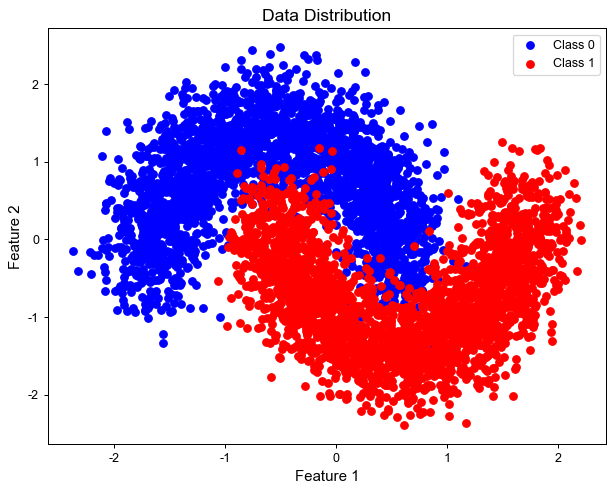

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 生成数据：n_samples 表示样本数量，noise 表示噪音水平
X, y = make_moons(n_samples=5000, noise=0.2, random_state=42)

# 数据标准化处理，使各特征均值为0、方差为1
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# 将数据划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.3, random_state=42)

# 绘制数据散点图，展示原始数据分布
plt.figure(figsize=(8,6))
plt.scatter(X_std[y==0, 0], X_std[y==0, 1], color='blue', label='Class 0')
plt.scatter(X_std[y==1, 0], X_std[y==1, 1], color='red', label='Class 1')
plt.xlabel("Feature 1", fontsize=12)   
plt.ylabel("Feature 2", fontsize=12)   
plt.title("Data Distribution", fontsize=14)  
plt.legend()
plt.show()

代码中，我们首先生成了一个包含5000个样本、噪音水平为0.2的双月数据集，并对数据进行了标准化处理。

![原文参考图，当前结果见代码输出](attachments/img_002.png)

数据被划分为训练集和测试集。接下来，我们绘制了数据分布图，可以看到数据在二维空间中的分布情况明显非线性，适合使用多项式核 SVM 来分类。

### 2. 模型训练

我们选择多项式核作为核函数，参数主要包括：

- `degree`：多项式的度数，决定了映射到高维空间后所考虑的多项式阶数；
- `gamma`：核系数，控制输入数据点内积的放缩效果；
- `coef0`：常数项，控制模型复杂度；
- `C`：SVM 的正则化参数，平衡训练误差与模型复杂度。

下面代码展示如何构建 SVM 模型，并利用多项式核训练模型：

In [3]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# 定义多项式核 SVM 模型，初始参数可调
svm_poly = SVC(kernel='poly', degree=3, gamma=1, coef0=1, C=1, random_state=42)

# 模型训练
svm_poly.fit(X_train, y_train)

# 模型预测
y_pred = svm_poly.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy: {:.2f}%".format(acc*100))

# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Test Accuracy: 97.27%
Confusion Matrix:
 [[713  17]
 [ 24 746]]


运行上述代码后，可以获得模型在测试集上的准确率和混淆矩阵。通过调节 `degree`、`gamma`、`coef0` 和 `C` 参数，我们可以进一步提高模型的分类效果。

### 3. 决策边界可视化

利用决策边界图展示模型在整个特征空间中的分割情况。决策边界可视化有助于理解模型如何处理非线性数据。

代码中，我们在整个特征空间中生成网格点，并预测每个网格点的类别，然后用等高线图绘制出决策边界：

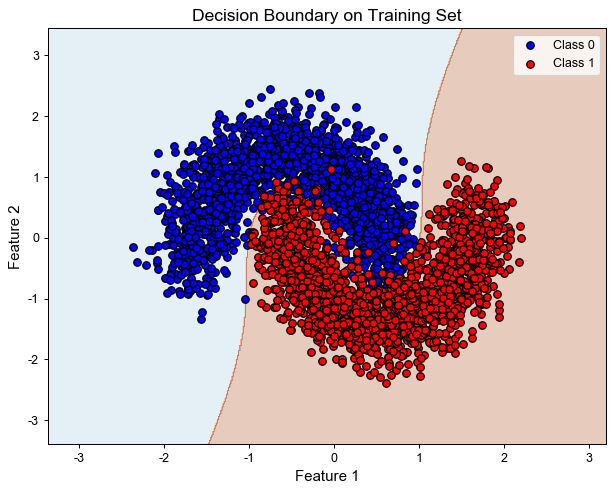

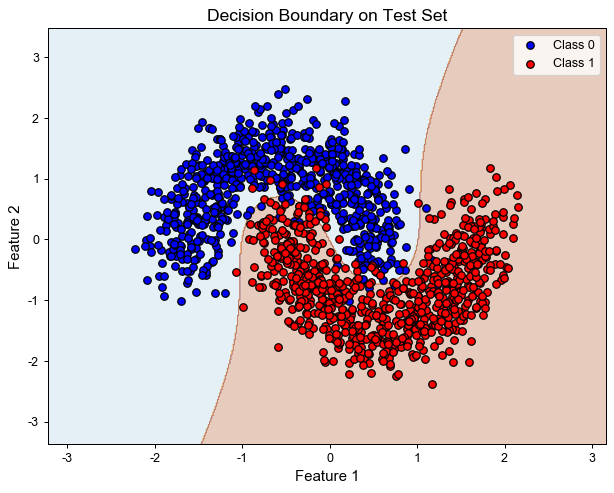

In [4]:
# 定义绘图函数：绘制决策边界和数据散点图
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # 设置图形大小
    plt.figure(figsize=(8, 6))
    
    # 生成网格点
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    
    # 对网格点进行预测
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制决策区域
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    
    # 绘制原始数据点
    plt.scatter(X[y==0, 0], X[y==0, 1], color='blue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], color='red', edgecolor='k', label='Class 1')
    
    plt.xlabel("Feature 1", fontsize=12)  
    plt.ylabel("Feature 2", fontsize=12)  
    plt.title(title, fontsize=14)         
    plt.legend()
    plt.show()

# 绘制训练集决策边界
plot_decision_boundary(svm_poly, X_train, y_train, title="Decision Boundary on Training Set")

# 绘制测试集决策边界
plot_decision_boundary(svm_poly, X_test, y_test, title="Decision Boundary on Test Set")

![原文参考图，当前结果见代码输出](attachments/img_003.png)

![原文参考图，当前结果见代码输出](attachments/img_004.png)

利用 `contourf` 方法绘制决策区域，并将训练数据和测试数据分别展示。可以清晰地看到模型如何利用多项式核构造非线性决策边界，有效地将两类样本分开。

### 4. 混淆矩阵可视化

混淆矩阵可以更直观地展示模型分类的正确率和错误类型，我们利用热力图对混淆矩阵进行可视化。

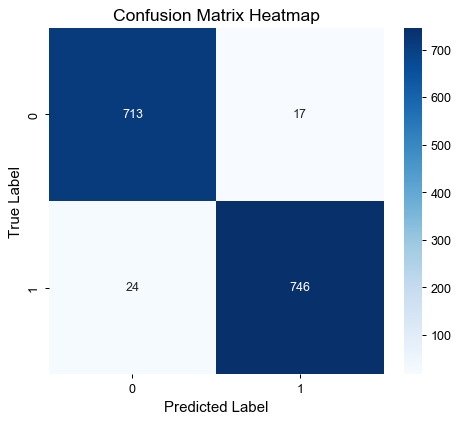

In [5]:
import seaborn as sns

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted Label", fontsize=12)  
    plt.ylabel("True Label", fontsize=12)       
    plt.title(title, fontsize=14)               
    plt.show()

# 绘制混淆矩阵热力图
plot_confusion_matrix(cm, title="Confusion Matrix Heatmap")

上述代码利用 seaborn 库生成混淆矩阵热力图，可以直观反映出模型在不同类别上的预测准确性和误分类情况。

![原文参考图，当前结果见代码输出](attachments/img_005.png)

### 5. 学习曲线分析

学习曲线可以帮助我们了解模型在不同训练集规模下的表现，以及模型是否存在过拟合或欠拟合的问题。

下面代码展示如何绘制训练误差和交叉验证误差的学习曲线：

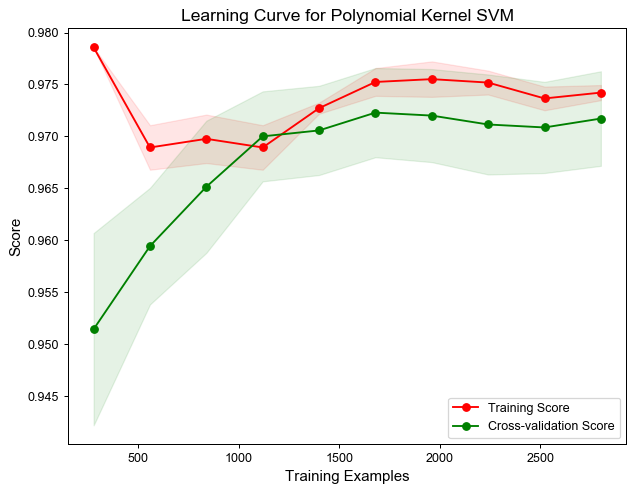

In [6]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title="Learning Curve", cv=5, n_jobs=1):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                                                            train_sizes=np.linspace(0.1, 1.0, 10), random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std  = np.std(train_scores, axis=1)
    test_scores_mean  = np.mean(test_scores, axis=1)
    test_scores_std   = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation Score')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='g')
    plt.xlabel("Training Examples", fontsize=12)  
    plt.ylabel("Score", fontsize=12)                
    plt.title(title, fontsize=14)                   
    plt.legend(loc="best")
    plt.show()

# 绘制学习曲线
plot_learning_curve(svm_poly, X_train, y_train, title="Learning Curve for Polynomial Kernel SVM")

![原文参考图，当前结果见代码输出](attachments/img_006.png)

在上面的代码中，我们利用 `learning_curve` 函数计算了不同训练样本数量下的得分，并绘制了均值和标准差区域，以便观察训练过程中的模型性能变化。如果训练得分和交叉验证得分之间存在较大差距，可能表明模型存在过拟合现象。

### 算法优化：网格搜索调参

为了进一步提升模型性能，我们采用网格搜索（GridSearchCV）方法，对 SVM 的关键超参数进行调优。主要调参项包括：

- `C`：正则化参数，控制误差项惩罚程度；
- `degree`：多项式核的度数；
- `gamma`：核函数的系数；
- `coef0`：多项式核中的常数项；

通过设置参数范围，让算法自动搜索最优组合。代码如下：

In [7]:
from sklearn.model_selection import GridSearchCV

# 定义参数网格
param_grid = {
    'C': [0.1, 1],
    'degree': [2, 3],
    'gamma': [0.1, 1],
    'coef0': [0, 1]
}

# 构建基于多项式核的 SVM 模型
svm_poly_cv = SVC(kernel='poly', random_state=42)

# 利用 GridSearchCV 进行超参数调优，cv 表示交叉验证次数
grid_search = GridSearchCV(svm_poly_cv, param_grid, cv=5, n_jobs=1, verbose=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 输出最佳参数及最佳得分
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score: {:.2f}%".format(grid_search.best_score_*100))

# 利用最佳参数构建模型，并在测试集上进行评估
best_svm_poly = grid_search.best_estimator_
y_pred_best = best_svm_poly.predict(X_test)
best_acc = accuracy_score(y_test, y_pred_best)
print("Test Accuracy with Best Parameters: {:.2f}%".format(best_acc*100))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best Parameters: {'C': 1, 'coef0': 1, 'degree': 3, 'gamma': 1}
Best Cross-validation Score: 97.17%
Test Accuracy with Best Parameters: 97.27%


网格搜索能够穷尽参数空间的组合，帮助我们找到使交叉验证得分最高的参数组合。调参完成后，我们利用最佳模型在测试集上进行评估，并输出最终的分类准确率。

### 分析与优化

通过前面的实验和可视化，我们可以得到以下几点分析结论：

1. **数据非线性特征明显**：通过 `make_moons` 数据集生成的样本显示出明显的非线性结构，传统线性模型难以对这种结构进行准确划分。因此，使用核函数（如多项式核）将数据映射到高维特征空间是十分必要的。
2. **多项式核的效果**：采用多项式核的 SVM 能够捕捉到数据中较高阶的非线性关系。通过决策边界的可视化，我们可以直观看到模型构造出的复杂曲线，能够较好地将两类数据分离。图中决策边界较为平滑，但在边界附近仍存在少量误分类情况。
3. **模型优化的重要性**：参数 `C`、`degree`、`gamma` 以及 `coef0` 对模型性能有显著影响。例如：

   - 较小的 `C` 值会使模型倾向于宽松的间隔，但可能引入欠拟合；
   - 较大的 `C` 值则可能过于拟合训练数据，导致泛化能力下降；
   - 多项式的度数 `degree` 决定了映射到高维空间后的复杂度，过高的度数可能会引入噪声，降低模型稳定性；
   - `gamma` 和 `coef0` 共同决定了多项式核的形状。
4. 因此，利用网格搜索对超参数进行调优可以大幅提升模型在测试集上的表现。通过交叉验证，我们能够客观评估不同参数组合下的模型表现，并选取最佳参数组合。
5. **多重可视化方法的意义**：通过决策边界图、混淆矩阵热力图和学习曲线，我们能够从多个角度评估模型的表现：

   - 决策边界图帮助理解模型如何将高维数据映射到低维空间后的分类效果；
   - 混淆矩阵可以直观展示模型对各个类别的预测准确率及误分类情况；
   - 学习曲线反映了训练样本数量对模型性能的影响，可以辅助判断是否存在欠拟合或过拟合问题。
6. **算法优化策略**：在实际应用中，除了网格搜索外，还可以考虑其他超参数调优方法（如随机搜索、贝叶斯优化等）来进一步提高模型效率和准确率。此外，结合数据预处理、特征工程和模型集成等方法也能显著改善分类性能。

## 模型分析

上面案例中，我们使用了**多项式核**处理了**非线性可分数据**，并与**线性核 SVM**进行对比。

多项式核虽然能够有效地处理某些非线性问题，但在不同场景下表现各异，下面进行详细分析。

### 多项式核优缺点

| **优势** | **劣势** |
|-|-|
| **能够处理非线性数据**：通过高维特征映射，使非线性数据变得线性可分。 | **计算复杂度高**：高阶多项式可能会导致维度灾难，计算代价大。 |
| **无须显式构造高维特征**：使用核技巧（Kernel Trick），避免直接计算高维特征空间。 | **参数敏感**：参数 $d$（多项式阶数）、$C$（正则化系数）和 $c$（偏置项）需要调优，否则可能出现过拟合或欠拟合。 |
| **适用于中小规模数据**：比 RBF 核（径向基核）更易解释，适用于特定领域，如图像分类、文本分类。 | **对噪声敏感**：高阶多项式容易拟合训练数据中的噪声，导致泛化能力下降。 |

### 多项式核 vs. 其他核方法

| **算法** | **适用场景** | **优点** | **缺点** |
|-|-|-|-|
| **线性核 SVM** | 线性可分数据 | 计算速度快、可解释性强 | 不能处理非线性数据 |
| **多项式核 SVM** | 低维非线性数据 | 可通过多项式映射捕捉特征 | 计算复杂度高，参数敏感 |
| **RBF 核 SVM** | 任意非线性数据 | 适用于高维复杂数据，决策边界灵活 | 需调优参数 $\gamma$，可解释性较差 |
| **Sigmoid 核 SVM** | 模拟神经网络 | 适用于部分模式识别问题 | 可能导致数值不稳定，易受参数影响 |

### 何时选择多项式核 SVM？

**推荐使用多项式核的情况**：

1. **数据是低维的**，但具有一定的**非线性**关系。
2. **特征工程已完成**，且特征之间存在交互作用（例如文本分类中 n-gram 关系）。
3. **希望结果更具可解释性**，相比 RBF 核，多项式核的映射方式更易理解。

**应考虑其他算法的情况**：

1. **数据维度很高**（如图像、基因数据）：使用 RBF 核或深度学习更合适。
2. **数据规模庞大**：多项式核计算复杂度较高，线性核或梯度提升树（GBDT）更高效。
3. **非线性关系复杂**：RBF 核通常比多项式核具有更好的决策边界。

## 最后

多项式核 **成功地捕捉了非线性特征**，且**相比于线性核，分类效果更好**。但如果数据维度过高，或者非线性关系更加复杂，**RBF 核**可能是更优的选择。如果数据是线性可分的，则**线性核 SVM 更简单高效**。